Generating pass-decision network data...
Creating and training network...
Training on cuda...


Training:   1%|█▍                                                                                                                                             | 1/100 [00:02<03:29,  2.11s/it]

Epoch 0, Loss: 177.811379, LR: 2.13e-04


Training:  51%|████████████████████████████████████████████████████████████████████████▍                                                                     | 51/100 [01:43<01:39,  2.02s/it]

Epoch 50, Loss: 0.532544, LR: 3.96e-03


Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [03:24<00:00,  2.04s/it]


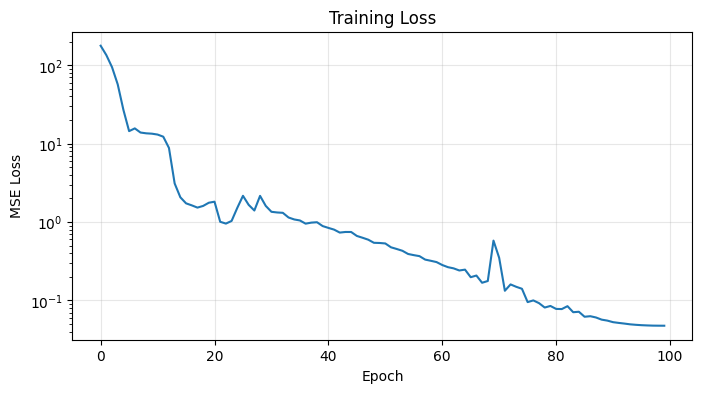

Analyzing network performance...
=== Network Performance Analysis ===
Pass Region MSE (Identity): 0.012936 ± 0.004994
Decision Region MSE: 0.037980 ± 0.028789
Communication MSE: 0.428975 ± 0.148795
Plotting example trial...


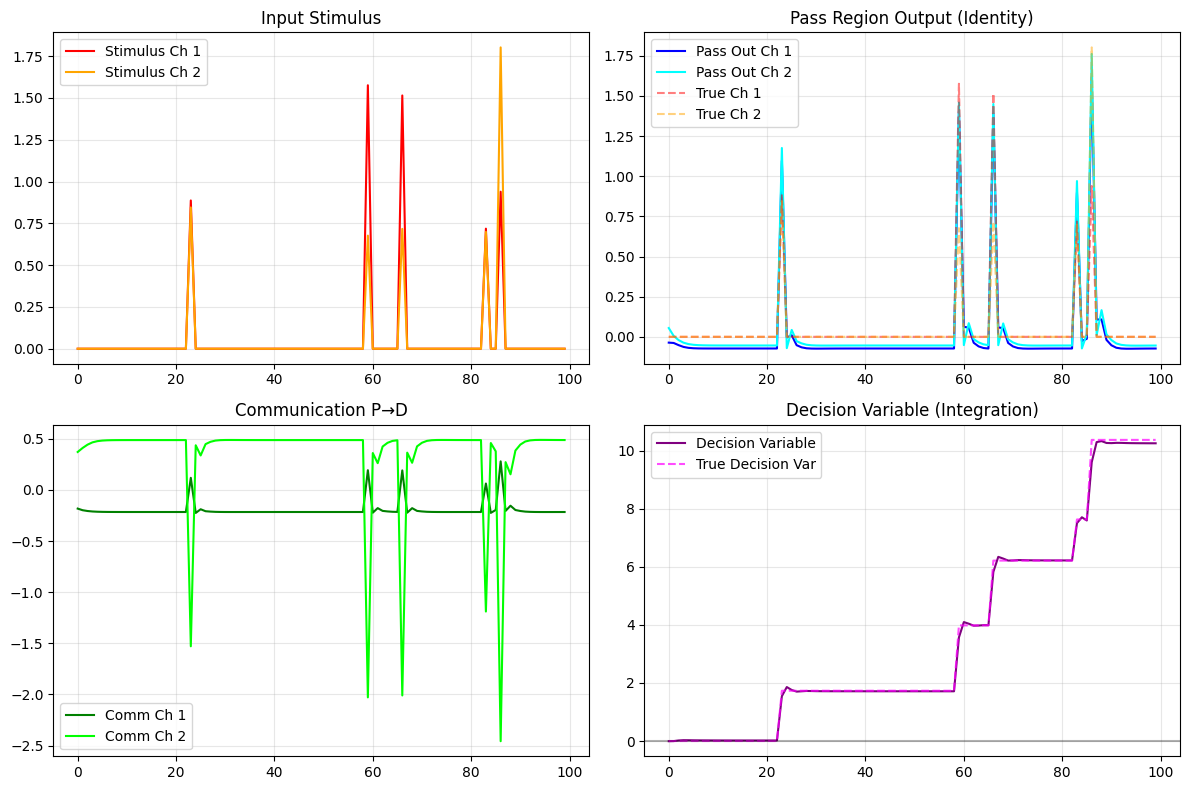

Final training loss: 0.047479


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.distributions import Exponential
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class PassDecisionNetwork(nn.Module):
    def __init__(self, hidden_dim=16):
        super().__init__()
        self.hidden_dim = hidden_dim
        
        # Pass region (AP) - learns identity function
        self.pass_gru = nn.GRU(input_size=2, hidden_size=hidden_dim, batch_first=True)
        self.pass_readout = nn.Linear(hidden_dim, 2)  # Output stimulus
        
        # Decision region (AD) - integrates signal
        self.decision_gru = nn.GRU(input_size=2, hidden_size=hidden_dim, batch_first=True)
        self.decision_readout = nn.Linear(hidden_dim, 1)  # Output decision variable
        
        # Communication from pass to decision
        self.comm_layer = nn.Linear(2, 2)  # Pass stimulus to decision
        
        self.to(device)
    
    def forward(self, stimulus, return_states=False):
        batch_size, seq_len, _ = stimulus.shape
        
        # Initialize hidden states
        h_pass = torch.zeros(1, batch_size, self.hidden_dim, device=device)
        h_decision = torch.zeros(1, batch_size, self.hidden_dim, device=device)
        
        pass_outputs = []
        decision_outputs = []
        communications = []
        decision_vars = []
        
        for t in range(seq_len):
            # Pass region receives stimulus and learns identity
            pass_out, h_pass = self.pass_gru(stimulus[:, t:t+1], h_pass)
            pass_output = self.pass_readout(pass_out.squeeze(1))
            pass_outputs.append(pass_output)
            
            # Communication: pass sends stimulus to decision
            comm_signal = self.comm_layer(pass_output)
            communications.append(comm_signal)
            
            # Decision region receives communication and integrates
            decision_out, h_decision = self.decision_gru(comm_signal.unsqueeze(1), h_decision)
            decision_output = self.decision_readout(decision_out.squeeze(1))
            decision_outputs.append(decision_output)
            
            # Decision variable accumulates over time
            if t == 0:
                decision_var = decision_output
            else:
                decision_var = decision_vars[-1] + decision_output
            decision_vars.append(decision_var)
        
        pass_outputs = torch.stack(pass_outputs, dim=1)
        decision_outputs = torch.stack(decision_outputs, dim=1)
        communications = torch.stack(communications, dim=1)
        decision_vars = torch.stack(decision_vars, dim=1)
        
        if return_states:
            return {
                'pass_outputs': pass_outputs,
                'decision_outputs': decision_outputs,
                'communications': communications,
                'decision_vars': decision_vars
            }
        
        return pass_outputs, decision_vars

def generate_pass_decision_data(n_trials=500, seq_len=100):
    """Generate data for pass-decision task"""
    data = []
    
    for trial in range(n_trials):
        # Generate stimulus sequence
        stimulus = torch.zeros(seq_len, 2)
        
        # Sample fewer, more sparse stimuli for clearer signal
        n_stimuli = torch.poisson(torch.tensor(3.0)).int().item()
        stim_times = torch.randint(5, seq_len-5, (n_stimuli,))
        
        for t in stim_times:
            # Smaller stimulus values for better learning
            stim_val = torch.rand(2) * 2 + 0.5  # Range [0.5, 2.5]
            stimulus[t] = stim_val
        
        # Ground truth targets
        pass_target = stimulus.clone()  # Identity function
        
        # Decision variable (cumulative sum of stimulus magnitude)
        decision_target = torch.cumsum(stimulus.sum(dim=1, keepdim=True), dim=0)
        
        data.append({
            'stimulus': stimulus,
            'pass_target': pass_target,
            'decision_target': decision_target,
            'communication_target': stimulus  # Ground truth communication
        })
    
    return data

def create_batched_data(data, batch_size=32):
    """Convert list of trials to batched tensors"""
    stimuli = torch.stack([d['stimulus'] for d in data])
    pass_targets = torch.stack([d['pass_target'] for d in data])
    decision_targets = torch.stack([d['decision_target'] for d in data])
    
    batches = []
    for i in range(0, len(data), batch_size):
        batch = {
            'stimulus': stimuli[i:i+batch_size].to(device),
            'pass_target': pass_targets[i:i+batch_size].to(device),
            'decision_target': decision_targets[i:i+batch_size].to(device)
        }
        batches.append(batch)
    
    return batches

def train_pass_decision_network(model, data, n_epochs=200, lr=1e-3, batch_size=32):
    """Train the pass-decision network with proper batching"""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr*5, epochs=n_epochs, 
                                            steps_per_epoch=len(data)//batch_size + 1)
    model.train()
    
    # Create batched data once
    batched_data = create_batched_data(data, batch_size)
    
    losses = []
    for epoch in tqdm(range(n_epochs), desc="Training"):
        total_loss = 0
        
        for batch in batched_data:
            optimizer.zero_grad()
            
            # Forward pass on entire batch
            pass_out, decision_var = model(batch['stimulus'])
            
            # Compute losses
            pass_loss = nn.MSELoss()(pass_out, batch['pass_target'])
            decision_loss = nn.MSELoss()(decision_var, batch['decision_target'])
            
            # Total loss
            loss = pass_loss + decision_loss
            loss.backward()
            
            # Gradient clipping for stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            scheduler.step()
            
            total_loss += loss.item()
        
        avg_loss = total_loss / len(batched_data)
        losses.append(avg_loss)
        
        if epoch % 50 == 0:
            tqdm.write(f"Epoch {epoch}, Loss: {avg_loss:.6f}, LR: {scheduler.get_last_lr()[0]:.2e}")
    
    model.eval()
    return losses

def plot_network_activity(model, test_data, trial_idx=0):
    """Plot network activity for visualization"""
    model.eval()
    
    with torch.no_grad():
        trial_data = test_data[trial_idx]
        stimulus = trial_data['stimulus'].unsqueeze(0).to(device)
        
        # Get network outputs
        results = model(stimulus, return_states=True)
        
        # Convert to numpy for plotting
        stimulus_np = stimulus.squeeze().cpu().numpy()
        pass_out = results['pass_outputs'].squeeze().cpu().numpy()
        comm = results['communications'].squeeze().cpu().numpy()
        decision_var = results['decision_vars'].squeeze().cpu().numpy()
        
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        
        # Plot stimulus
        axes[0,0].plot(stimulus_np[:, 0], label='Stimulus Ch 1', color='red')
        axes[0,0].plot(stimulus_np[:, 1], label='Stimulus Ch 2', color='orange')
        axes[0,0].set_title('Input Stimulus')
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)
        
        # Plot pass region output
        axes[0,1].plot(pass_out[:, 0], label='Pass Out Ch 1', color='blue')
        axes[0,1].plot(pass_out[:, 1], label='Pass Out Ch 2', color='cyan')
        axes[0,1].plot(stimulus_np[:, 0], '--', alpha=0.5, label='True Ch 1', color='red')
        axes[0,1].plot(stimulus_np[:, 1], '--', alpha=0.5, label='True Ch 2', color='orange')
        axes[0,1].set_title('Pass Region Output (Identity)')
        axes[0,1].legend()
        axes[0,1].grid(True, alpha=0.3)
        
        # Plot communication
        axes[1,0].plot(comm[:, 0], label='Comm Ch 1', color='green')
        axes[1,0].plot(comm[:, 1], label='Comm Ch 2', color='lime')
        axes[1,0].set_title('Communication P→D')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)
        
        # Plot decision variable
        axes[1,1].plot(decision_var.flatten(), label='Decision Variable', color='purple')
        axes[1,1].plot(trial_data['decision_target'].flatten(), '--', 
                      alpha=0.7, label='True Decision Var', color='magenta')
        axes[1,1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
        axes[1,1].set_title('Decision Variable (Integration)')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

def analyze_network_performance(model, test_data):
    """Analyze network performance on different metrics"""
    model.eval()
    
    pass_errors = []
    decision_errors = []
    comm_errors = []
    
    with torch.no_grad():
        for trial_data in test_data[:50]:  # Analyze first 50 trials
            stimulus = trial_data['stimulus'].unsqueeze(0).to(device)
            
            results = model(stimulus, return_states=True)
            
            # Pass region error (identity function)
            pass_error = nn.MSELoss()(
                results['pass_outputs'].squeeze(),
                trial_data['stimulus'].to(device)
            ).item()
            pass_errors.append(pass_error)
            
            # Decision variable error
            decision_error = nn.MSELoss()(
                results['decision_vars'].squeeze(),
                trial_data['decision_target'].squeeze().to(device)
            ).item()
            decision_errors.append(decision_error)
            
            # Communication error (should match stimulus)
            comm_error = nn.MSELoss()(
                results['communications'].squeeze(),
                trial_data['stimulus'].to(device)
            ).item()
            comm_errors.append(comm_error)
    
    print("=== Network Performance Analysis ===")
    print(f"Pass Region MSE (Identity): {np.mean(pass_errors):.6f} ± {np.std(pass_errors):.6f}")
    print(f"Decision Region MSE: {np.mean(decision_errors):.6f} ± {np.std(decision_errors):.6f}")
    print(f"Communication MSE: {np.mean(comm_errors):.6f} ± {np.std(comm_errors):.6f}")
    
    return {
        'pass_errors': pass_errors,
        'decision_errors': decision_errors,
        'comm_errors': comm_errors
    }

if __name__ == "__main__":
    # Set random seeds
    torch.manual_seed(42)
    np.random.seed(42)
    
    print("Generating pass-decision network data...")
    train_data = generate_pass_decision_data(n_trials=800, seq_len=100)
    test_data = generate_pass_decision_data(n_trials=200, seq_len=100)
    
    print("Creating and training network...")
    model = PassDecisionNetwork(hidden_dim=16)
    
    print(f"Training on {device}...")
    losses = train_pass_decision_network(model, train_data, n_epochs=100, lr=1e-3, batch_size=64)
    
    # Plot training curve
    plt.figure(figsize=(8, 4))
    plt.plot(losses)
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print("Analyzing network performance...")
    performance = analyze_network_performance(model, test_data)
    
    print("Plotting example trial...")
    plot_network_activity(model, test_data, trial_idx=5)
    
    print(f"Final training loss: {losses[-1]:.6f}")

Using device: cuda
No cached model found. Training Multi-Region RNN...


Training Multi-Region RNN:   1%|█▎                                                                                                                            | 1/100 [00:15<25:15, 15.31s/it]

Epoch 0: Total=0.8661, Evidence=0.8217, Motor=0.0445


Training Multi-Region RNN:  21%|██████████████████████████▎                                                                                                  | 21/100 [01:24<04:40,  3.54s/it]

Epoch 20: Total=0.0550, Evidence=0.0431, Motor=0.0120


...

Epoch 60: Total=0.0073, Evidence=0.0031, Motor=0.0043


Training Multi-Region RNN:  81%|█████████████████████████████████████████████████████████████████████████████████████████████████████▎                       | 81/100 [04:54<01:06,  3.50s/it]

Epoch 80: Total=0.0070, Evidence=0.0020, Motor=0.0049


Training Multi-Region RNN: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [06:02<00:00,  3.62s/it]


Saved model and losses to cache/decision_motor_rnn


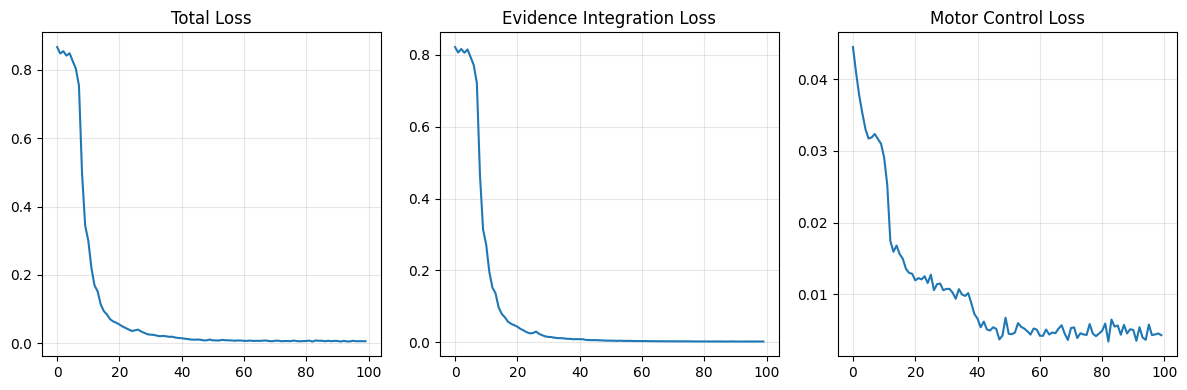

Analyzing your trained model...
Extracting trajectories from trained model...

Analyzing Evidence Region...
Evidence PCA explained variance: [0.86226326 0.09192955 0.01771777]


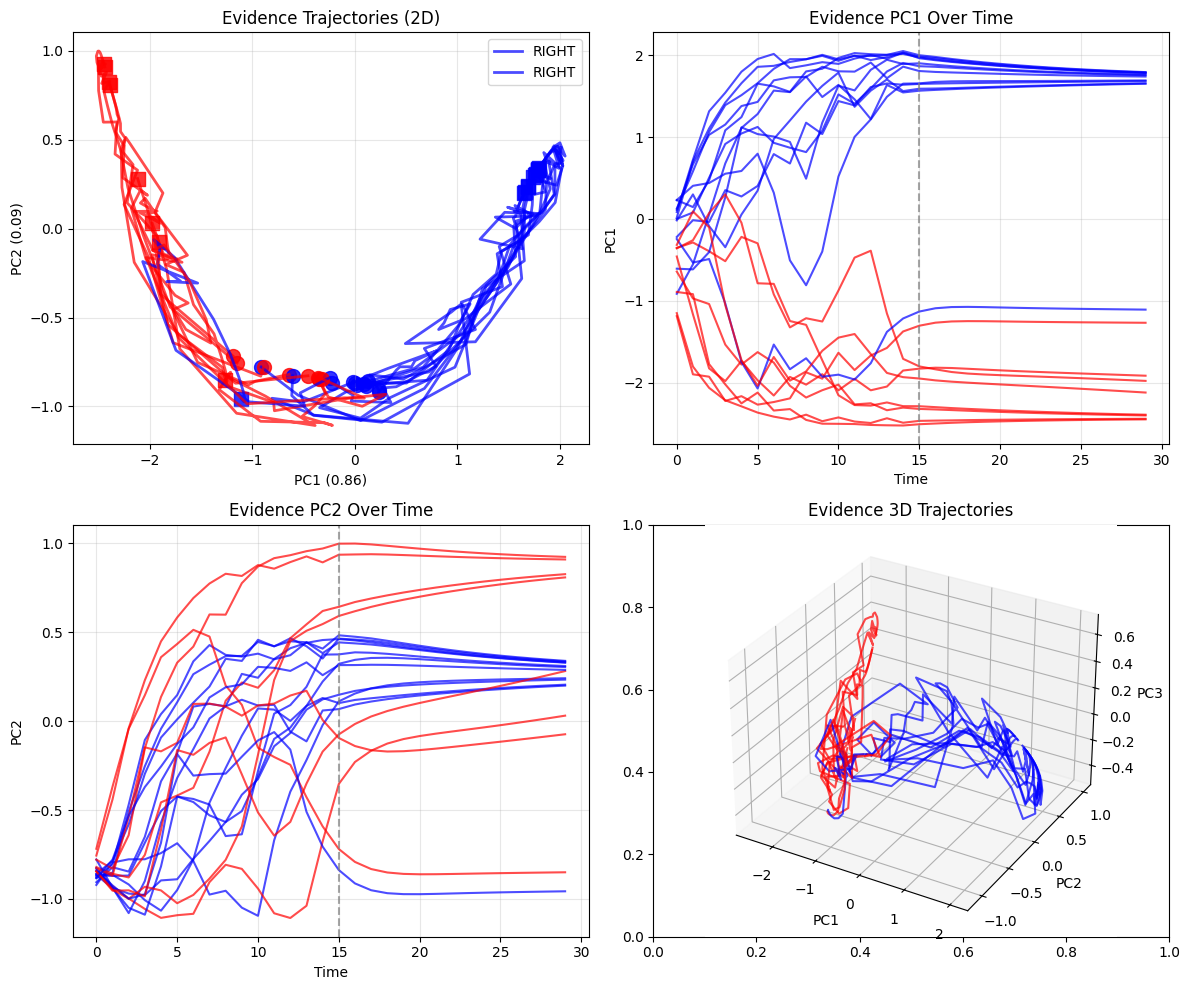


Analyzing Motor Region...
Motor PCA explained variance: [0.39499128 0.30793414 0.18350883]


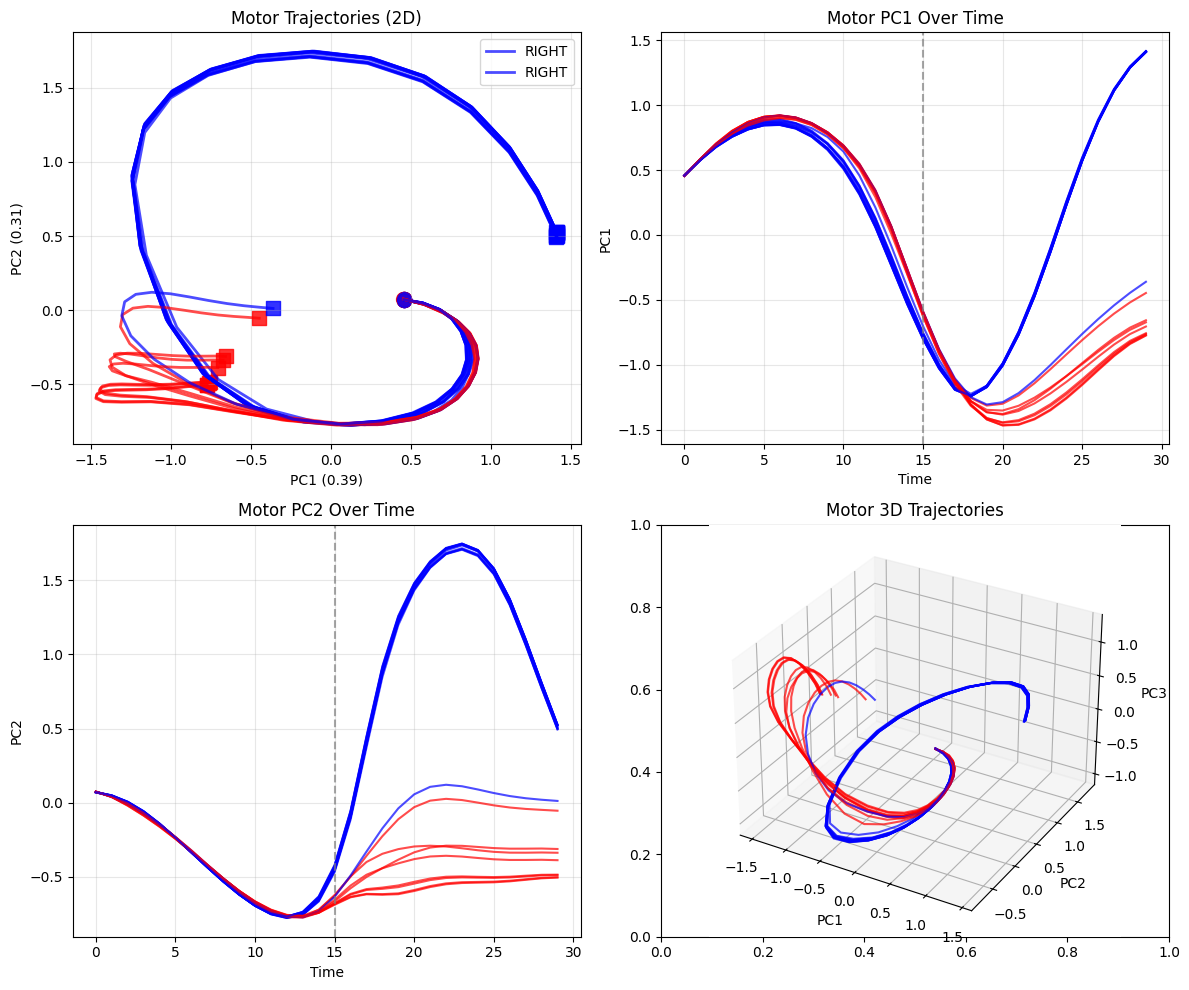


Analyzing Communication...


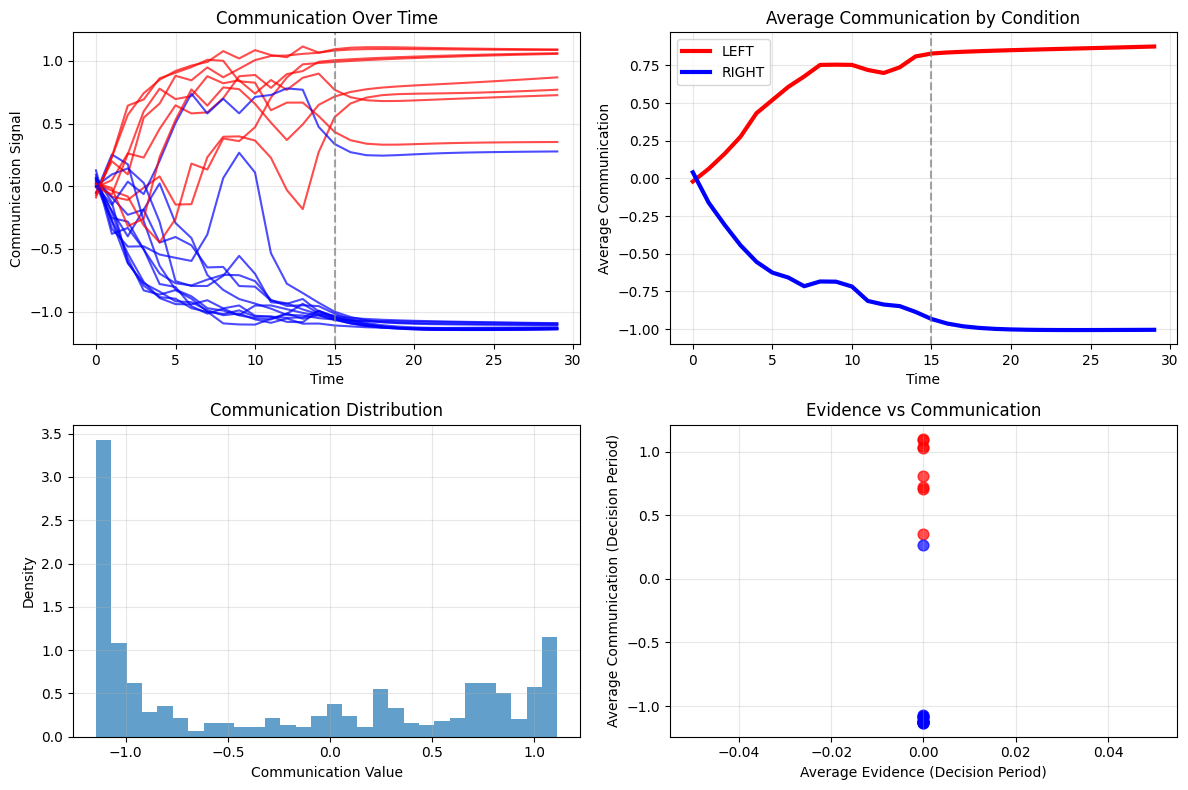

Training complete! Model saved as 'trained_model'


In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns


# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Task parameters
SEQUENCE_LENGTH = 30
EVIDENCE_PHASE = 15  # First 40 steps have evidence
RESPONSE_STEP = 29   # Must be correct at step 49
BATCH_SIZE = 128
N_TRIALS = 1000
COHERENCE = 0.8      # Evidence strength
NOISE_LEVEL = 0.5    # Evidence noise

def generate_task_data(batch_size, sequence_length, coherence=0.3, noise_level=0.5):
    """Generate evidence integration + reaching task data"""
    
    # Random target direction for each trial (0=LEFT, 1=RIGHT)
    targets = torch.randint(0, 2, (batch_size,), device=device)
    
    # Evidence streams (first 40 timesteps)
    evidence = torch.zeros(batch_size, sequence_length, 2, device=device)
    evidence[:, :EVIDENCE_PHASE, 0] = (1 - targets.float()).unsqueeze(1) * coherence + \
                                      torch.randn(batch_size, EVIDENCE_PHASE, device=device) * noise_level
    evidence[:, :EVIDENCE_PHASE, 1] = targets.float().unsqueeze(1) * coherence + \
                                      torch.randn(batch_size, EVIDENCE_PHASE, device=device) * noise_level
    
    # True evidence integration (teaching signal for Region 1)
    true_integration = torch.cumsum(evidence[:, :, 1] - evidence[:, :, 0], dim=1)
    true_integration = torch.tanh(true_integration)  # Bounded integration
    
    # Target reach trajectories (teaching signal for Region 2)
    target_positions = torch.zeros(batch_size, sequence_length, 2, device=device)
    target_velocities = torch.zeros(batch_size, sequence_length, 2, device=device)
    
    for i in range(batch_size):
        if targets[i] == 0:  # LEFT reach
            target_positions[i, :, 0] = -1.0  # x = -1
            target_positions[i, :, 1] = 0.0   # y = 0
        else:  # RIGHT reach  
            target_positions[i, :, 0] = 1.0   # x = 1
            target_positions[i, :, 1] = 0.0   # y = 0
    
    # Smooth velocity trajectories (start moving after evidence phase)
    for t in range(EVIDENCE_PHASE, sequence_length):
        progress = (t - EVIDENCE_PHASE) / (sequence_length - EVIDENCE_PHASE)
        smooth_vel = 0.5 * np.sin(np.pi * progress) if progress < 1.0 else 0.0
        
        for i in range(batch_size):
            if targets[i] == 0:  # LEFT
                target_velocities[i, t, 0] = -smooth_vel
            else:  # RIGHT
                target_velocities[i, t, 0] = smooth_vel
    
    return {
        'evidence': evidence,
        'targets': targets,
        'true_integration': true_integration,
        'target_positions': target_positions,
        'target_velocities': target_velocities
    }

class MultiRegionRNN(nn.Module):
    def __init__(self, evidence_hidden=64, motor_hidden=64):
        super().__init__()
        
        # Region 1: Evidence Integrator
        self.evidence_rnn = nn.LSTM(
            input_size=2,  # [evidence_left, evidence_right]
            hidden_size=evidence_hidden,
            batch_first=True
        )
        self.evidence_output = nn.Linear(evidence_hidden, 1)  # Integrated evidence
        
        # Region 2: Motor Controller  
        self.motor_rnn = nn.LSTM(
            input_size=3,  # [communication_from_R1, position_x, position_y]
            hidden_size=motor_hidden,
            batch_first=True
        )
        self.motor_output = nn.Linear(motor_hidden, 2)  # [velocity_x, velocity_y]
        
        # Communication layer (Region 1 → Region 2)
        self.communication = nn.Linear(evidence_hidden, 1)
        
        self.evidence_hidden_size = evidence_hidden
        self.motor_hidden_size = motor_hidden
        
    def forward(self, evidence_input):
        batch_size, seq_len, _ = evidence_input.shape
        
        # Initialize motor state
        motor_position = torch.zeros(batch_size, seq_len, 2, device=evidence_input.device)
        motor_velocity = torch.zeros(batch_size, seq_len, 2, device=evidence_input.device)
        
        # Storage for outputs
        evidence_outputs = []
        motor_outputs = []
        communications = []
        
        # Initialize hidden states
        evidence_hidden = (torch.zeros(1, batch_size, self.evidence_hidden_size, device=evidence_input.device),
                          torch.zeros(1, batch_size, self.evidence_hidden_size, device=evidence_input.device))
        motor_hidden = (torch.zeros(1, batch_size, self.motor_hidden_size, device=evidence_input.device),
                       torch.zeros(1, batch_size, self.motor_hidden_size, device=evidence_input.device))
        
        for t in range(seq_len):
            # Region 1: Evidence Integration
            evidence_out, evidence_hidden = self.evidence_rnn(
                evidence_input[:, t:t+1, :], evidence_hidden
            )
            integrated_evidence = self.evidence_output(evidence_out.squeeze(1))
            evidence_outputs.append(integrated_evidence)
            
            # Communication: Region 1 → Region 2
            comm_signal = self.communication(evidence_out.squeeze(1))
            communications.append(comm_signal)
            
            # Region 2: Motor Control
            motor_input = torch.cat([
                comm_signal,
                motor_position[:, t, :]
            ], dim=1).unsqueeze(1)
            
            motor_out, motor_hidden = self.motor_rnn(motor_input, motor_hidden)
            velocity_output = torch.tanh(self.motor_output(motor_out.squeeze(1)))
            motor_outputs.append(velocity_output)
            
            # Update motor state for next timestep
            if t < seq_len - 1:
                motor_velocity[:, t+1, :] = velocity_output
                motor_position[:, t+1, :] = motor_position[:, t, :] + velocity_output * 0.1
        
        return {
            'evidence_integration': torch.stack(evidence_outputs, dim=1),
            'motor_velocity': torch.stack(motor_outputs, dim=1),
            'communication': torch.stack(communications, dim=1),
            'motor_position': motor_position
        }

def train_multi_region_rnn():
    """Train multi-region RNN efficiently"""
    
    # Initialize model
    model = MultiRegionRNN(evidence_hidden=64, motor_hidden=64).to(device)
    model = torch.compile(model)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=5e-3, epochs=100, steps_per_epoch=N_TRIALS//BATCH_SIZE
    )
    
    # Training loop
    losses = []
    evidence_losses = []
    motor_losses = []
    
    for epoch in tqdm(range(100), desc="Training Multi-Region RNN"):
        epoch_loss = 0
        epoch_evidence_loss = 0
        epoch_motor_loss = 0
        
        for batch_idx in range(N_TRIALS // BATCH_SIZE):
            # Generate batch
            batch_data = generate_task_data(BATCH_SIZE, SEQUENCE_LENGTH)
            
            # Forward pass
            outputs = model(batch_data['evidence'])
            
            # Loss computation
            # Region 1 loss: Evidence integration accuracy
            evidence_loss = nn.MSELoss()(
                outputs['evidence_integration'], 
                batch_data['true_integration'].unsqueeze(-1)
            )
            
            # Region 2 loss: Motor control accuracy  
            motor_loss = nn.MSELoss()(
                outputs['motor_velocity'],
                batch_data['target_velocities']
            )
            
            # Combined loss
            total_loss = evidence_loss + motor_loss
            
            # Backward pass
            optimizer.zero_grad()
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            
            epoch_loss += total_loss.item()
            epoch_evidence_loss += evidence_loss.item()
            epoch_motor_loss += motor_loss.item()
        
        # Record losses
        avg_loss = epoch_loss / (N_TRIALS // BATCH_SIZE)
        avg_evidence_loss = epoch_evidence_loss / (N_TRIALS // BATCH_SIZE)
        avg_motor_loss = epoch_motor_loss / (N_TRIALS // BATCH_SIZE)
        
        losses.append(avg_loss)
        evidence_losses.append(avg_evidence_loss)
        motor_losses.append(avg_motor_loss)
        
        if epoch % 20 == 0:
            print(f"Epoch {epoch}: Total={avg_loss:.4f}, Evidence={avg_evidence_loss:.4f}, Motor={avg_motor_loss:.4f}")
    
    return model, losses, evidence_losses, motor_losses

def analyze_trained_model(model):
    """Analyze the trained multi-region RNN"""
    model.eval()
    
    with torch.no_grad():
        # Generate test data
        test_data = generate_task_data(5, SEQUENCE_LENGTH, coherence=0.5)
        outputs = model(test_data['evidence'])
        
        # Plot results
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        # Evidence integration
        for trial in range(3):
            axes[0, trial].plot(outputs['evidence_integration'][trial].cpu(), 
                              label='RNN Integration', linewidth=2)
            axes[0, trial].plot(test_data['true_integration'][trial].cpu(), 
                              label='True Integration', linestyle='--')
            axes[0, trial].axvline(x=EVIDENCE_PHASE, color='red', linestyle=':', alpha=0.7)
            axes[0, trial].set_title(f'Trial {trial+1}: Evidence Integration')
            axes[0, trial].legend()
            axes[0, trial].grid(True, alpha=0.3)
        
        # Motor control
        for trial in range(3):
            axes[1, trial].plot(outputs['motor_velocity'][trial, :, 0].cpu(), 
                              label='RNN Velocity X', linewidth=2)
            axes[1, trial].plot(test_data['target_velocities'][trial, :, 0].cpu(), 
                              label='Target Velocity X', linestyle='--')
            axes[1, trial].axvline(x=EVIDENCE_PHASE, color='red', linestyle=':', alpha=0.7)
            axes[1, trial].set_title(f'Trial {trial+1}: Motor Control')
            axes[1, trial].legend()
            axes[1, trial].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Communication analysis
        plt.figure(figsize=(12, 4))
        for trial in range(3):
            plt.subplot(1, 3, trial+1)
            plt.plot(outputs['communication'][trial].cpu(), linewidth=2)
            plt.axvline(x=EVIDENCE_PHASE, color='red', linestyle=':', alpha=0.7)
            plt.title(f'Communication Signal (Trial {trial+1})')
            plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

def generate_task_data(batch_size, sequence_length, coherence=0.3, noise_level=0.5):
    """Generate evidence integration + reaching task data"""
    
    # Random target direction for each trial (0=LEFT, 1=RIGHT)
    targets = torch.randint(0, 2, (batch_size,), device=device)
    
    # Evidence streams (first 15 timesteps)
    evidence = torch.zeros(batch_size, sequence_length, 2, device=device)
    evidence[:, :EVIDENCE_PHASE, 0] = (1 - targets.float()).unsqueeze(1) * coherence + \
                                      torch.randn(batch_size, EVIDENCE_PHASE, device=device) * noise_level
    evidence[:, :EVIDENCE_PHASE, 1] = targets.float().unsqueeze(1) * coherence + \
                                      torch.randn(batch_size, EVIDENCE_PHASE, device=device) * noise_level
    
    # True evidence integration (teaching signal for Region 1)
    true_integration = torch.cumsum(evidence[:, :, 1] - evidence[:, :, 0], dim=1)
    true_integration = torch.tanh(true_integration)  # Bounded integration
    
    # Target reach trajectories (teaching signal for Region 2)
    target_positions = torch.zeros(batch_size, sequence_length, 2, device=device)
    target_velocities = torch.zeros(batch_size, sequence_length, 2, device=device)
    
    for i in range(batch_size):
        if targets[i] == 0:  # LEFT reach
            target_positions[i, :, 0] = -1.0  # x = -1
            target_positions[i, :, 1] = 0.0   # y = 0
        else:  # RIGHT reach  
            target_positions[i, :, 0] = 1.0   # x = 1
            target_positions[i, :, 1] = 0.0   # y = 0
    
    # Smooth velocity trajectories (start moving after evidence phase)
    for t in range(EVIDENCE_PHASE, sequence_length):
        progress = (t - EVIDENCE_PHASE) / (sequence_length - EVIDENCE_PHASE)
        smooth_vel = 0.5 * np.sin(np.pi * progress) if progress < 1.0 else 0.0
        
        for i in range(batch_size):
            if targets[i] == 0:  # LEFT
                target_velocities[i, t, 0] = -smooth_vel
            else:  # RIGHT
                target_velocities[i, t, 0] = smooth_vel
    
    return {
        'evidence': evidence,
        'targets': targets,
        'true_integration': true_integration,
        'target_positions': target_positions,
        'target_velocities': target_velocities
    }

def extract_trajectories(model, n_trials=10):
    """Extract hidden state trajectories from trained model"""
    model.eval()
    
    evidence_states = []
    motor_states = []
    communications = []
    trial_info = []
    
    with torch.no_grad():
        for trial_idx in range(n_trials):
            batch_data = generate_task_data(1, SEQUENCE_LENGTH)  # Single trial
            
            # Run model and collect hidden states
            evidence_hiddens = []
            motor_hiddens = []
            comms = []
            
            evidence_hidden = (torch.zeros(1, 1, model.evidence_hidden_size, device=device),
                              torch.zeros(1, 1, model.evidence_hidden_size, device=device))
            motor_hidden = (torch.zeros(1, 1, model.motor_hidden_size, device=device),
                           torch.zeros(1, 1, model.motor_hidden_size, device=device))
            
            motor_position = torch.zeros(1, 2, device=device)
            
            for t in range(SEQUENCE_LENGTH):
                # Evidence region
                evidence_out, evidence_hidden = model.evidence_rnn(
                    batch_data['evidence'][:, t:t+1, :], evidence_hidden
                )
                evidence_hiddens.append(evidence_hidden[0].squeeze().cpu().numpy())
                
                # Communication
                comm = model.communication(evidence_out.squeeze(1))
                comms.append(comm.cpu().numpy())
                
                # Motor region
                motor_input = torch.cat([comm, motor_position], dim=1).unsqueeze(1)
                motor_out, motor_hidden = model.motor_rnn(motor_input, motor_hidden)
                motor_hiddens.append(motor_hidden[0].squeeze().cpu().numpy())
                
                # Update motor position
                velocity = torch.tanh(model.motor_output(motor_out.squeeze(1)))
                motor_position = motor_position + velocity * 0.1
            
            evidence_states.append(np.array(evidence_hiddens))
            motor_states.append(np.array(motor_hiddens))
            communications.append(np.array(comms).squeeze())
            trial_info.append({
                'target': batch_data['targets'].item(),
                'evidence': batch_data['evidence'].squeeze().cpu().numpy(),
                'true_integration': batch_data['true_integration'].squeeze().cpu().numpy()
            })
    
    return {
        'evidence_states': np.array(evidence_states),  # [n_trials, time, hidden_dim]
        'motor_states': np.array(motor_states),
        'communications': np.array(communications),
        'trial_info': trial_info
    }

def plot_trajectories_pca(trajectories, region_name='Evidence'):
    """Plot trajectories in PCA space"""
    states = trajectories['evidence_states'] if region_name == 'Evidence' else trajectories['motor_states']
    n_trials, n_time, n_dim = states.shape
    
    # Fit PCA on all data
    all_states = states.reshape(-1, n_dim)
    pca = PCA(n_components=min(3, n_dim))
    pca.fit(all_states)
    
    print(f"{region_name} PCA explained variance: {pca.explained_variance_ratio_[:3]}")
    
    # Transform trajectories
    states_pca = np.zeros((n_trials, n_time, pca.n_components_))
    for trial in range(n_trials):
        states_pca[trial] = pca.transform(states[trial])
    
    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # 2D trajectory plot colored by target
    for trial in range(n_trials):
        target = trajectories['trial_info'][trial]['target']
        color = 'red' if target == 0 else 'blue'
        label = 'LEFT' if target == 0 else 'RIGHT'
        
        if trial == 0 or (trial == 1 and target == 1):  # Add labels only once per condition
            axes[0,0].plot(states_pca[trial, :, 0], states_pca[trial, :, 1], 
                          color=color, alpha=0.7, linewidth=2, label=label)
        else:
            axes[0,0].plot(states_pca[trial, :, 0], states_pca[trial, :, 1], 
                          color=color, alpha=0.7, linewidth=2)
        
        # Mark start and end
        axes[0,0].scatter(states_pca[trial, 0, 0], states_pca[trial, 0, 1], 
                         color=color, s=100, marker='o', alpha=0.8)
        axes[0,0].scatter(states_pca[trial, -1, 0], states_pca[trial, -1, 1], 
                         color=color, s=100, marker='s', alpha=0.8)
    
    axes[0,0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2f})')
    axes[0,0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2f})')
    axes[0,0].set_title(f'{region_name} Trajectories (2D)')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # PC1 over time
    for trial in range(n_trials):
        target = trajectories['trial_info'][trial]['target']
        color = 'red' if target == 0 else 'blue'
        axes[0,1].plot(states_pca[trial, :, 0], color=color, alpha=0.7)
    
    axes[0,1].axvline(x=EVIDENCE_PHASE, color='gray', linestyle='--', alpha=0.7)
    axes[0,1].set_xlabel('Time')
    axes[0,1].set_ylabel('PC1')
    axes[0,1].set_title(f'{region_name} PC1 Over Time')
    axes[0,1].grid(True, alpha=0.3)
    
    # PC2 over time
    for trial in range(n_trials):
        target = trajectories['trial_info'][trial]['target']
        color = 'red' if target == 0 else 'blue'
        axes[1,0].plot(states_pca[trial, :, 1], color=color, alpha=0.7)
    
    axes[1,0].axvline(x=EVIDENCE_PHASE, color='gray', linestyle='--', alpha=0.7)
    axes[1,0].set_xlabel('Time')
    axes[1,0].set_ylabel('PC2')
    axes[1,0].set_title(f'{region_name} PC2 Over Time')
    axes[1,0].grid(True, alpha=0.3)
    
    # 3D plot if available
    if pca.n_components_ >= 3:
        ax = fig.add_subplot(224, projection='3d')
        for trial in range(n_trials):
            target = trajectories['trial_info'][trial]['target']
            color = 'red' if target == 0 else 'blue'
            ax.plot(states_pca[trial, :, 0], states_pca[trial, :, 1], states_pca[trial, :, 2], 
                   color=color, alpha=0.7)
        
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.set_zlabel('PC3')
        ax.set_title(f'{region_name} 3D Trajectories')
    
    plt.tight_layout()
    plt.show()
    
    return pca, states_pca

def plot_communication_analysis(trajectories):
    """Analyze communication between regions"""
    comms = trajectories['communications']  # [n_trials, time]
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # Communication over time by condition
    for trial in range(len(trajectories['trial_info'])):
        target = trajectories['trial_info'][trial]['target']
        color = 'red' if target == 0 else 'blue'
        axes[0,0].plot(comms[trial], color=color, alpha=0.7)
    
    axes[0,0].axvline(x=EVIDENCE_PHASE, color='gray', linestyle='--', alpha=0.7)
    axes[0,0].set_xlabel('Time')
    axes[0,0].set_ylabel('Communication Signal')
    axes[0,0].set_title('Communication Over Time')
    axes[0,0].grid(True, alpha=0.3)
    
    # Average communication by condition
    left_trials = [i for i, info in enumerate(trajectories['trial_info']) if info['target'] == 0]
    right_trials = [i for i, info in enumerate(trajectories['trial_info']) if info['target'] == 1]
    
    if left_trials:
        avg_comm_left = np.mean(comms[left_trials], axis=0)
        axes[0,1].plot(avg_comm_left, color='red', linewidth=3, label='LEFT')
    
    if right_trials:
        avg_comm_right = np.mean(comms[right_trials], axis=0)
        axes[0,1].plot(avg_comm_right, color='blue', linewidth=3, label='RIGHT')
    
    axes[0,1].axvline(x=EVIDENCE_PHASE, color='gray', linestyle='--', alpha=0.7)
    axes[0,1].set_xlabel('Time')
    axes[0,1].set_ylabel('Average Communication')
    axes[0,1].set_title('Average Communication by Condition')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    
    # Communication distribution
    all_comms = comms.flatten()
    axes[1,0].hist(all_comms, bins=30, alpha=0.7, density=True)
    axes[1,0].set_xlabel('Communication Value')
    axes[1,0].set_ylabel('Density')
    axes[1,0].set_title('Communication Distribution')
    axes[1,0].grid(True, alpha=0.3)
    
    # Evidence vs Communication scatter
    for trial in range(len(trajectories['trial_info'])):
        evidence = trajectories['trial_info'][trial]['evidence'][:, 0]  # Evidence signal
        target = trajectories['trial_info'][trial]['target']
        color = 'red' if target == 0 else 'blue'
        
        # Use evidence in second half (decision period)
        evidence_decision = np.mean(evidence[EVIDENCE_PHASE:])
        comm_decision = np.mean(comms[trial, EVIDENCE_PHASE:])
        
        axes[1,1].scatter(evidence_decision, comm_decision, color=color, alpha=0.7, s=60)
    
    axes[1,1].set_xlabel('Average Evidence (Decision Period)')
    axes[1,1].set_ylabel('Average Communication (Decision Period)')
    axes[1,1].set_title('Evidence vs Communication')
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def analyze_model_behavior(model):
    """Complete analysis of trained model"""
    print("Extracting trajectories from trained model...")
    trajectories = extract_trajectories(model, n_trials=20)
    
    print("\nAnalyzing Evidence Region...")
    pca_evidence, states_pca_evidence = plot_trajectories_pca(trajectories, 'Evidence')
    
    print("\nAnalyzing Motor Region...")
    pca_motor, states_pca_motor = plot_trajectories_pca(trajectories, 'Motor')
    
    print("\nAnalyzing Communication...")
    plot_communication_analysis(trajectories)
    
    return trajectories, pca_evidence, pca_motor


import os
import torch

def load_trained_model():
    """Load cached model and training data if available"""
    cache_dir = "cache/decision_motor_rnn"
    model_path = os.path.join(cache_dir, "model.pt")
    losses_path = os.path.join(cache_dir, "losses.pt")
    
    if os.path.exists(model_path) and os.path.exists(losses_path):
        print("Loading cached model and losses...")
        
        # Load model
        model = MultiRegionRNN(evidence_hidden=64, motor_hidden=64).to(device)
        model.load_state_dict(torch.load(model_path, map_location=device))
        
        # Load losses
        losses_data = torch.load(losses_path, map_location=device)
        losses = losses_data['losses']
        evidence_losses = losses_data['evidence_losses'] 
        motor_losses = losses_data['motor_losses']
        
        print(f"Loaded model with {len(losses)} training epochs")
        return model, losses, evidence_losses, motor_losses, True
    
    return None, None, None, None, False

def save_trained_model(model, losses, evidence_losses, motor_losses):
    """Save model and training data to cache"""
    cache_dir = "cache/decision_motor_rnn"
    os.makedirs(cache_dir, exist_ok=True)
    
    # Save model
    model_path = os.path.join(cache_dir, "model.pt")
    torch.save(model.state_dict(), model_path)
    
    # Save losses
    losses_path = os.path.join(cache_dir, "losses.pt")
    losses_data = {
        'losses': losses,
        'evidence_losses': evidence_losses,
        'motor_losses': motor_losses
    }
    torch.save(losses_data, losses_path)
    
    print(f"Saved model and losses to {cache_dir}")



# trained_model, losses, evidence_losses, motor_losses, loaded = load_trained_model()
loaded = False
if not loaded:
    # Train if not cached
    print("No cached model found. Training Multi-Region RNN...")
    trained_model, losses, evidence_losses, motor_losses = train_multi_region_rnn()

# Save after training
save_trained_model(trained_model, losses, evidence_losses, motor_losses)
    
# Plot training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(losses)
plt.title('Total Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(evidence_losses)
plt.title('Evidence Integration Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(motor_losses)
plt.title('Motor Control Loss')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Run the analysis on your trained model
print("Analyzing your trained model...")
trajectories, pca_evidence, pca_motor = analyze_model_behavior(trained_model)

print("Training complete! Model saved as 'trained_model'")

In [ ]:
def extract_trajectories_multiregion(model, n_trials=800):
    """Extract normalized multi-region trajectories"""
    model.eval()
    
    evidence_states = []
    motor_states = []
    trial_info = []
    
    with torch.no_grad():
        for trial_idx in tqdm(range(n_trials), desc="Extracting trajectories"):
            batch_data = generate_task_data(1, SEQUENCE_LENGTH)
            
            evidence_hiddens = []
            motor_hiddens = []
            
            evidence_hidden = (torch.zeros(1, 1, model.evidence_hidden_size, device=device),
                              torch.zeros(1, 1, model.evidence_hidden_size, device=device))
            motor_hidden = (torch.zeros(1, 1, model.motor_hidden_size, device=device),
                           torch.zeros(1, 1, model.motor_hidden_size, device=device))
            
            motor_position = torch.zeros(1, 2, device=device)
            
            for t in range(SEQUENCE_LENGTH):
                # Evidence region
                evidence_out, evidence_hidden = model.evidence_rnn(
                    batch_data['evidence'][:, t:t+1, :], evidence_hidden
                )
                evidence_hiddens.append(evidence_hidden[0].squeeze())
                
                # Communication
                comm = model.communication(evidence_out.squeeze(1))
                
                # Motor region
                motor_input = torch.cat([comm, motor_position], dim=1).unsqueeze(1)
                motor_out, motor_hidden = model.motor_rnn(motor_input, motor_hidden)
                motor_hiddens.append(motor_hidden[0].squeeze())
                
                # Update motor position
                velocity = torch.tanh(model.motor_output(motor_out.squeeze(1)))
                motor_position = motor_position + velocity * 0.1
            
            evidence_states.append(torch.stack(evidence_hiddens))
            motor_states.append(torch.stack(motor_hiddens))
            trial_info.append({
                'target': batch_data['targets'].item(),
                'evidence': batch_data['evidence'].squeeze().cpu().numpy(),
                'true_integration': batch_data['true_integration'].squeeze().cpu().numpy()
            })
    
    # Stack and normalize
    evidence_states = torch.stack(evidence_states)
    motor_states = torch.stack(motor_states)
    
    # Normalize to prevent training instabilities
    evidence_mean = evidence_states.mean(dim=(0, 1), keepdim=True)
    evidence_std = evidence_states.std(dim=(0, 1), keepdim=True) + 1e-6
    evidence_states = (evidence_states - evidence_mean) / evidence_std
    
    motor_mean = motor_states.mean(dim=(0, 1), keepdim=True)
    motor_std = motor_states.std(dim=(0, 1), keepdim=True) + 1e-6
    motor_states = (motor_states - motor_mean) / motor_std
    
    return {
        'evidence_states': evidence_states,
        'motor_states': motor_states,
        'trial_info': trial_info,
        'normalization': {
            'evidence': (evidence_mean, evidence_std),
            'motor': (motor_mean, motor_std)
        }
    }


class MultiRegionLFADS(nn.Module):
    def __init__(self, region_dims, latent_dim=20, factors_dim=10, gen_dim=64, input_dim=5):
        super().__init__()
        self.n_regions = len(region_dims)
        self.region_dims = region_dims
        self.latent_dim = latent_dim
        self.factors_dim = factors_dim
        self.input_dim = input_dim
        
        # Encoders for each region
        self.encoders = nn.ModuleList([
            nn.LSTM(dim, gen_dim, bidirectional=True, batch_first=True)
            for dim in region_dims
        ])
        
        # Initial condition encoders
        self.ic_encoders = nn.ModuleList([
            nn.Sequential(
                nn.Linear(gen_dim * 2, gen_dim),
                nn.ReLU(),
                nn.Linear(gen_dim, latent_dim * 2)  # mean and logvar
            ) for _ in range(self.n_regions)
        ])
        
        # Input inference encoder (for u_t)
        self.input_encoder = nn.LSTM(
            sum(region_dims),  # Concatenated regions
            gen_dim,
            bidirectional=True,
            batch_first=True
        )
        
        # Input inference network (outputs u_t parameters at each timestep)
        self.input_inf_net = nn.Sequential(
            nn.Linear(gen_dim * 2, gen_dim),
            nn.ReLU(),
            nn.Linear(gen_dim, input_dim * 2)  # mean and logvar for each timestep
        )
        
        # Generator RNN with input inference
        self.generator = nn.LSTM(
            latent_dim + input_dim,  # z0 + u_t
            gen_dim,
            batch_first=True
        )
        
        # Factor decoders for each region
        self.factor_decoders = nn.ModuleList([
            nn.Linear(gen_dim, factors_dim) for _ in range(self.n_regions)
        ])
        
        # Output decoders for each region
        self.decoders = nn.ModuleList([
            nn.Sequential(
                nn.Linear(factors_dim, dim * 2),
                nn.ReLU(),
                nn.Linear(dim * 2, dim)
            ) for dim in region_dims
        ])
        
        # Xavier initialization
        self._init_weights()
    
    def _init_weights(self):
        """Initialize weights using Xavier initialization"""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.LSTM):
                for name, param in m.named_parameters():
                    if 'weight_ih' in name:
                        nn.init.xavier_normal_(param.data)
                    elif 'weight_hh' in name:
                        nn.init.orthogonal_(param.data)
                    elif 'bias' in name:
                        nn.init.constant_(param.data, 0)
                        # Set forget gate bias to 1
                        n = param.size(0)
                        param.data[n//4:n//2].fill_(1)
    
    def encode(self, x_regions):
        """Encode observations to latent initial conditions"""
        ics = []
        encodings = []
        
        for i, x in enumerate(x_regions):
            h, _ = self.encoders[i](x)
            encodings.append(h)
            # Use final hidden state for IC
            h_final = h[:, -1, :]
            ic_params = self.ic_encoders[i](h_final)
            ic_mean, ic_logvar = ic_params.chunk(2, dim=-1)
            ics.append((ic_mean, ic_logvar))
        
        return ics, encodings
    
    def infer_inputs(self, x_regions):
        """Infer time-varying inputs u_t"""
        # Concatenate all regions
        x_concat = torch.cat(x_regions, dim=-1)
        
        # Encode full sequence
        h_input, _ = self.input_encoder(x_concat)
        
        # Get input parameters for each timestep
        input_params = self.input_inf_net(h_input)
        input_mean, input_logvar = input_params.chunk(2, dim=-1)
        
        return input_mean, input_logvar
    
    def reparameterize(self, mean, logvar):
        """VAE reparameterization trick"""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mean + eps * std
    
    def generate(self, z0, u_t, seq_len):
        """Generate latent dynamics with inferred inputs"""
        batch_size = z0.size(0)
        
        # Initialize hidden state
        h = torch.zeros(1, batch_size, self.generator.hidden_size).to(z0.device)
        c = torch.zeros(1, batch_size, self.generator.hidden_size).to(z0.device)
        
        outputs = []
        z = z0
        
        for t in range(seq_len):
            # Concatenate latent state with inferred input
            gen_input = torch.cat([z, u_t[:, t, :]], dim=-1).unsqueeze(1)
            
            # Generate next state
            out, (h, c) = self.generator(gen_input, (h, c))
            outputs.append(out.squeeze(1))
            
            # Update latent state (optional: can keep z0 or evolve it)
            z = z0  # Keep initial condition
        
        z_gen = torch.stack(outputs, dim=1)
        return z_gen
    
    def decode(self, z_gen):
        """Decode latent states to observations"""
        factors = [self.factor_decoders[i](z_gen) for i in range(self.n_regions)]
        outputs = [self.decoders[i](f) for i, f in enumerate(factors)]
        return outputs, factors
    
    def forward(self, x_regions):
        seq_len = x_regions[0].size(1)
        
        # Encode for ICs
        ics, _ = self.encode(x_regions)
        
        # Infer inputs
        input_mean, input_logvar = self.infer_inputs(x_regions)
        u_t = self.reparameterize(input_mean, input_logvar)
        
        # Sample latent ICs
        z0s = [self.reparameterize(mean, logvar) for mean, logvar in ics]
        z0 = torch.mean(torch.stack(z0s), dim=0)  # Combine region ICs
        
        # Generate dynamics with inputs
        z_gen = self.generate(z0, u_t, seq_len)
        
        # Decode
        x_recon, factors = self.decode(z_gen)
        
        return {
            'recon': x_recon,
            'factors': factors,
            'ics': ics,
            'z_gen': z_gen,
            'input_params': (input_mean, input_logvar),
            'u_t': u_t
        }

def train_lfads_with_inputs(model, trajectories, n_epochs=200, batch_size=32, lr=1e-3):
    """Train multi-region LFADS with input inference"""
    
    # Initialize LFADS with input inference
    lfads = MultiRegionLFADS(
        region_dims=[model.evidence_hidden_size, model.motor_hidden_size],
        latent_dim=32,
        factors_dim=32,
        gen_dim=64,
        input_dim=10  # Dimension of inferred inputs
    ).to(device)
    
    optimizer = optim.Adam(lfads.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, n_epochs)
    
    # Get data
    evidence_states = trajectories['evidence_states']
    motor_states = trajectories['motor_states']
    n_trials = evidence_states.shape[0]
    
    losses = []
    recon_losses = []
    kl_ic_losses = []
    kl_input_losses = []
    
    for epoch in tqdm(range(n_epochs), desc="Training LFADS with Inputs"):
        # Shuffle data
        perm = torch.randperm(n_trials)
        
        epoch_loss = 0
        epoch_recon_loss = 0
        epoch_kl_ic_loss = 0
        epoch_kl_input_loss = 0
        n_batches = 0
        
        # Mini-batch training
        for i in range(0, n_trials, batch_size):
            batch_indices = perm[i:i+batch_size]
            
            # Get batch
            batch_evidence = evidence_states[batch_indices]
            batch_motor = motor_states[batch_indices]
            
            # Forward pass
            outputs = lfads([batch_evidence, batch_motor])
            
            # Reconstruction loss
            recon_loss = 0
            for j, (x_true, x_recon) in enumerate(zip([batch_evidence, batch_motor], outputs['recon'])):
                recon_loss += nn.MSELoss()(x_recon, x_true)
            
            # KL divergence loss for initial conditions
            kl_ic_loss = 0
            for mean, logvar in outputs['ics']:
                kl_ic_loss += -0.5 * torch.sum(1 + logvar - mean.pow(2) - logvar.exp())
            kl_ic_loss = kl_ic_loss / batch_evidence.size(0)
            
            # KL divergence loss for inferred inputs
            input_mean, input_logvar = outputs['input_params']
            kl_input_loss = -0.5 * torch.sum(
                1 + input_logvar - input_mean.pow(2) - input_logvar.exp()
            )
            kl_input_loss = kl_input_loss / (batch_evidence.size(0) * batch_evidence.size(1))
            
            # Total loss with KL annealing
            kl_weight = min(1.0, epoch / 50)
            total_loss = recon_loss + kl_weight * 0.1 * (kl_ic_loss + kl_input_loss)
            
            # Backward pass
            optimizer.zero_grad()
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(lfads.parameters(), 1.0)
            optimizer.step()
            
            # Accumulate losses
            epoch_loss += total_loss.item()
            epoch_recon_loss += recon_loss.item()
            epoch_kl_ic_loss += kl_ic_loss.item()
            epoch_kl_input_loss += kl_input_loss.item()
            n_batches += 1
        
        scheduler.step()
        
        # Average losses
        avg_loss = epoch_loss / n_batches
        avg_recon_loss = epoch_recon_loss / n_batches
        avg_kl_ic_loss = epoch_kl_ic_loss / n_batches
        avg_kl_input_loss = epoch_kl_input_loss / n_batches
        
        losses.append(avg_loss)
        recon_losses.append(avg_recon_loss)
        kl_ic_losses.append(avg_kl_ic_loss)
        kl_input_losses.append(avg_kl_input_loss)
        
        if epoch % 50 == 0:
            print(f"Epoch {epoch}: Total={avg_loss:.4f}, Recon={avg_recon_loss:.4f}, "
                  f"KL_IC={avg_kl_ic_loss:.4f}, KL_Input={avg_kl_input_loss:.4f}")
    
    return lfads, losses, recon_losses, kl_ic_losses, kl_input_losses

print("Extracting 800 trajectories from trained RNN...")
trajectories_large = extract_trajectories_multiregion(trained_model, n_trials=800)

print(f"Evidence states shape: {trajectories_large['evidence_states'].shape}")
print(f"Motor states shape: {trajectories_large['motor_states'].shape}")


# Train LFADS with input inference
print("\nTraining Multi-Region LFADS with Input Inference...")
lfads_input_model, total_losses, recon_losses, kl_ic_losses, kl_input_losses = train_lfads_with_inputs(
    trained_model, 
    trajectories_large,
    n_epochs=300,
    batch_size=32,
    lr=1e-3
)

# Plot training curves with all components
plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.plot(total_losses)
plt.title('Total Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 4, 2)
plt.plot(recon_losses)
plt.title('Reconstruction Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 4, 3)
plt.plot(kl_ic_losses)
plt.title('KL Loss (Initial Conditions)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 4, 4)
plt.plot(kl_input_losses)
plt.title('KL Loss (Inferred Inputs)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analyze inferred inputs
def analyze_inferred_inputs(lfads, trajectories_subset):
    """Analyze the inferred inputs u_t"""
    lfads.eval()
    
    with torch.no_grad():
        # Use first 20 trials for visualization
        evidence_states = trajectories_subset['evidence_states'][:20]
        motor_states = trajectories_subset['motor_states'][:20]
        
        outputs = lfads([evidence_states, motor_states])
        u_t = outputs['u_t'].cpu().numpy()
    
    # Plot inferred inputs
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # First few input dimensions over time
    for dim in range(min(4, u_t.shape[-1])):
        ax = axes[dim//2, dim%2]
        
        for trial in range(min(10, u_t.shape[0])):
            target = trajectories_subset['trial_info'][trial]['target']
            color = 'red' if target == 0 else 'blue'
            ax.plot(u_t[trial, :, dim], color=color, alpha=0.5)
        
        ax.axvline(x=EVIDENCE_PHASE, color='gray', linestyle='--', alpha=0.5)
        ax.set_title(f'Inferred Input Dimension {dim+1}')
        ax.set_xlabel('Time')
        ax.set_ylabel('Input Value')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return u_t

print("\nAnalyzing inferred inputs...")
# Create subset for analysis (first 20 trials)
trajectories_subset = {
    'evidence_states': trajectories_large['evidence_states'][:20],
    'motor_states': trajectories_large['motor_states'][:20],
    'trial_info': trajectories_large['trial_info'][:20]
}
inferred_inputs = analyze_inferred_inputs(lfads_input_model, trajectories_subset)

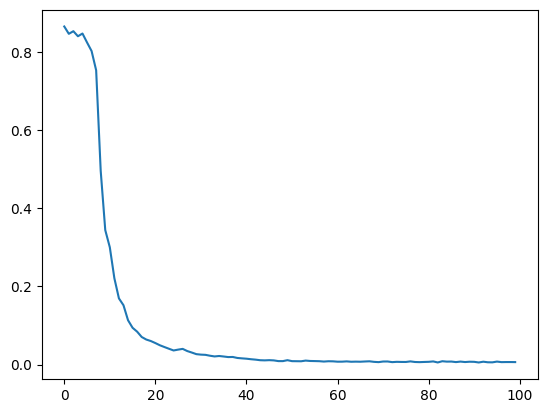

In [27]:
plt.plot(losses)

Performing detailed LFADS analysis...

=== Reconstruction Metrics ===
Evidence Region MSE: 0.036277
Motor Region MSE: 0.003946
Total MSE: 0.020111
Evidence R²: 0.962
Motor R²: 0.996

Plotting individual neuron responses...


C:\Users\xander\AppData\Local\Temp\ipykernel_22236\2381271241.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  evidence_states = torch.tensor(trajectories['evidence_states'], dtype=torch.float32).to(device)
C:\Users\xander\AppData\Local\Temp\ipykernel_22236\2381271241.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  motor_states = torch.tensor(trajectories['motor_states'], dtype=torch.float32).to(device)


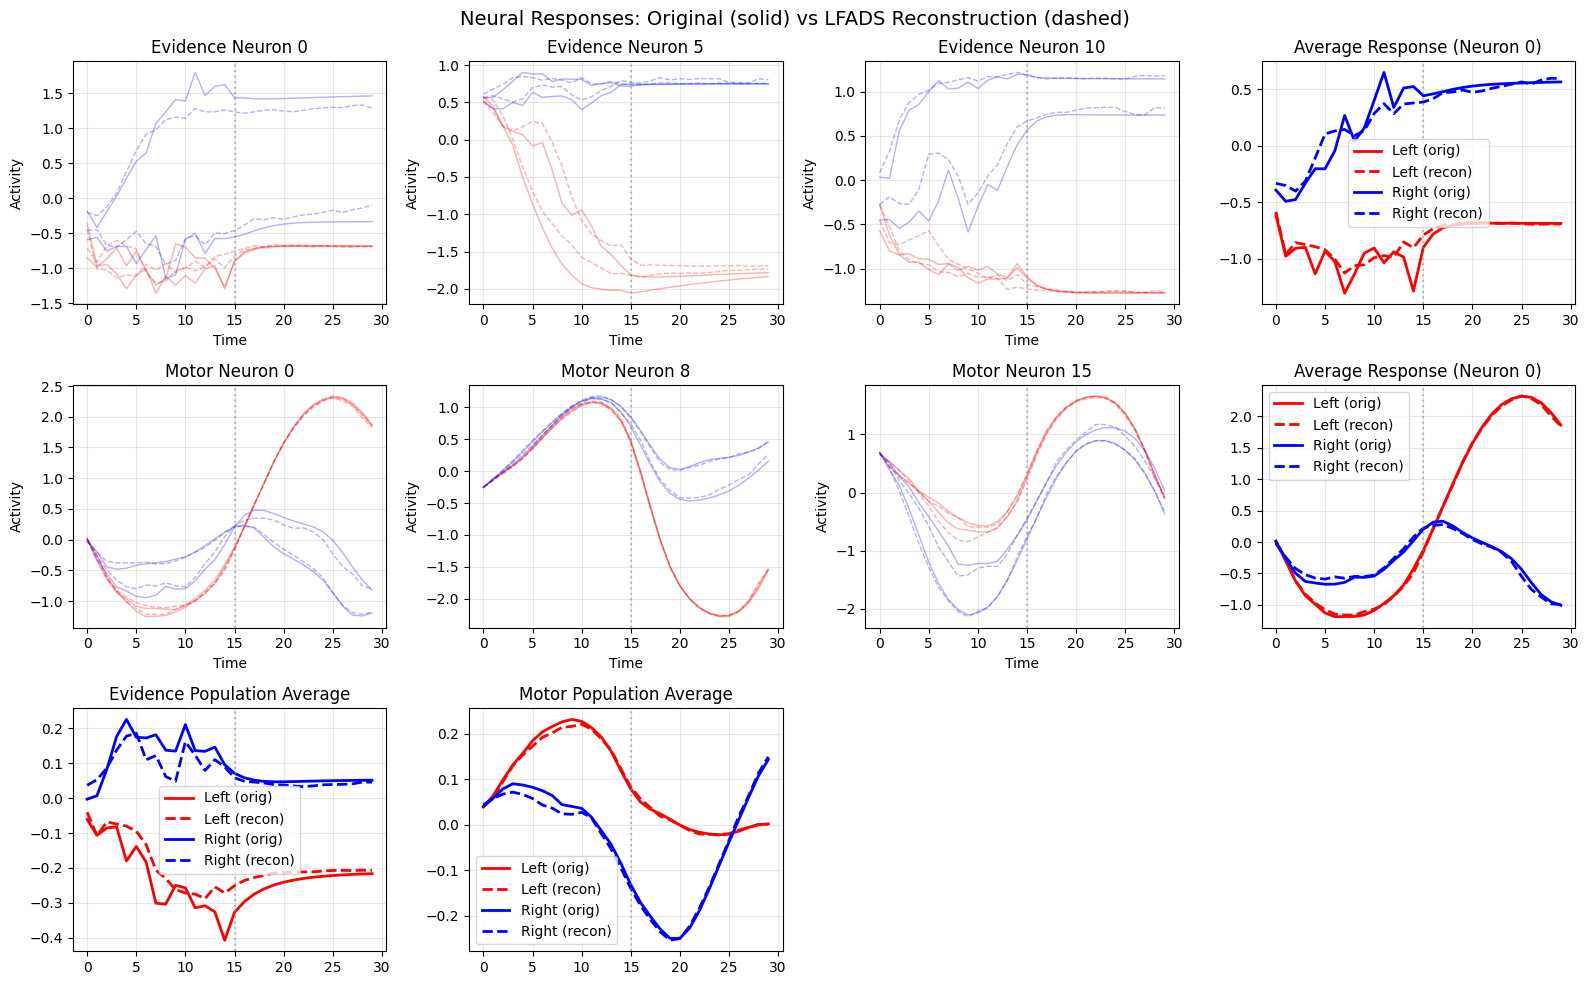


Comparing PCA dynamics...


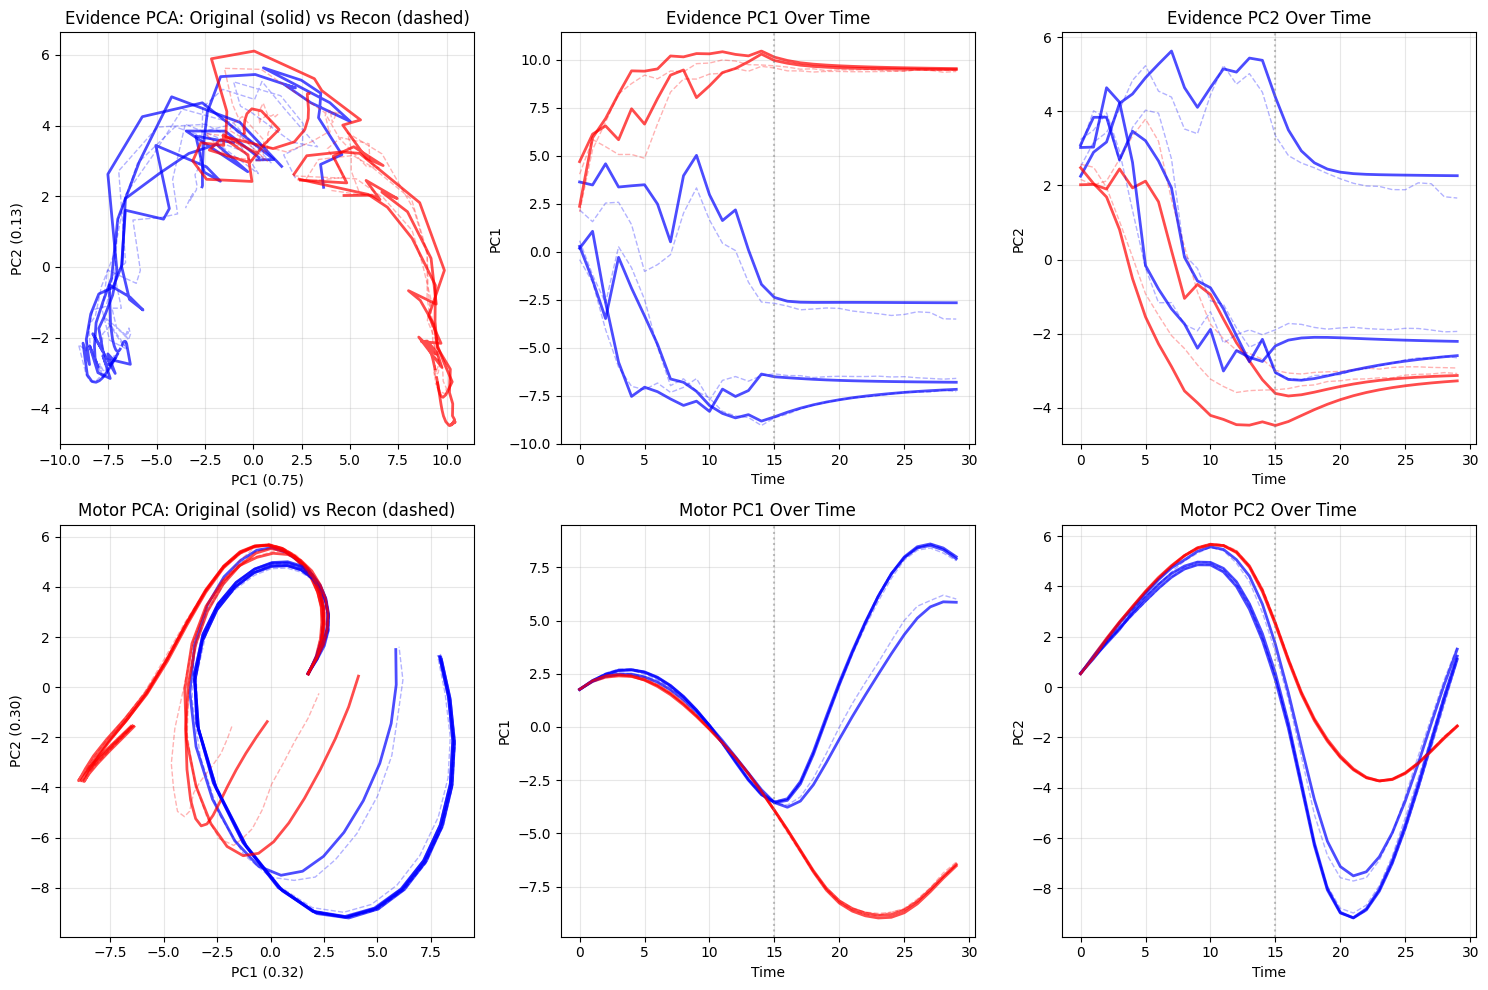


Analyzing full model components...


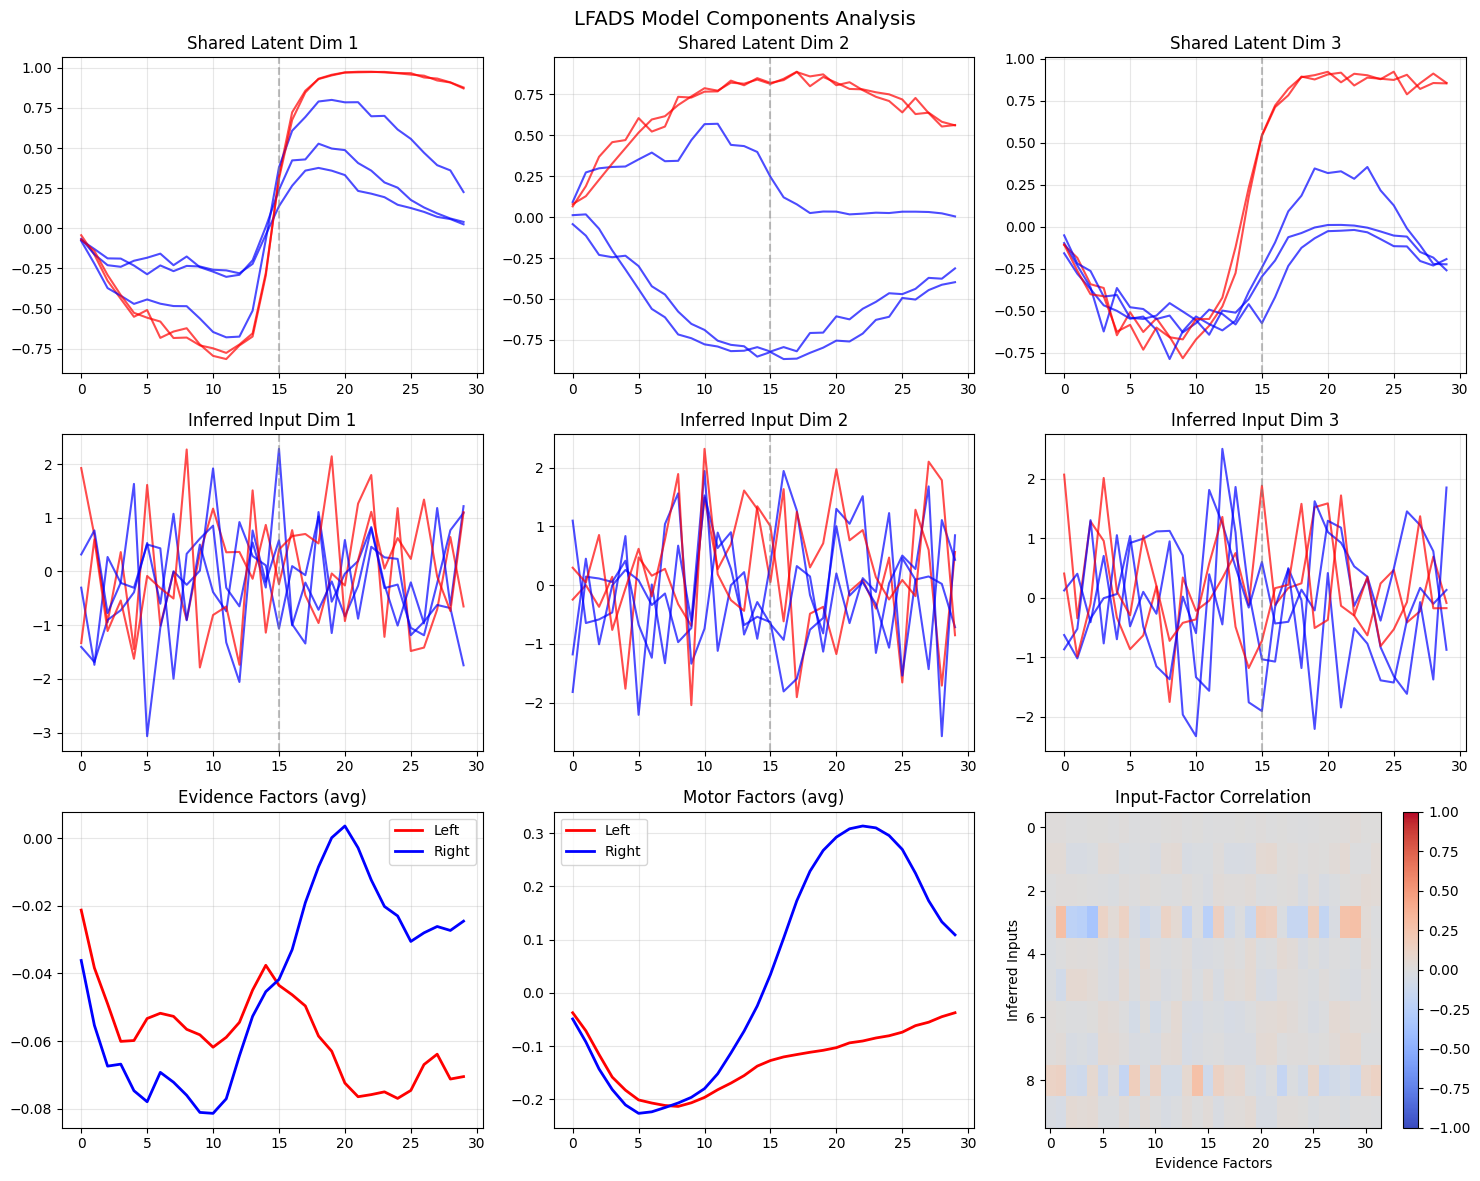


=== Model Component Dimensions ===
Shared latent dynamics: (50, 30, 64)
Inferred inputs: (50, 30, 10)
Evidence factors: (50, 30, 32)
Motor factors: (50, 30, 32)

Variance captured by factors:
Evidence factors: 0.571
Motor factors: 0.987


In [31]:
def analyze_lfads_detailed(lfads, trajectories, trained_model):
    """Detailed analysis of LFADS reconstruction quality"""
    lfads.eval()
    
    with torch.no_grad():
        evidence_states = torch.tensor(trajectories['evidence_states'], dtype=torch.float32).to(device)
        motor_states = torch.tensor(trajectories['motor_states'], dtype=torch.float32).to(device)
        
        outputs = lfads([evidence_states, motor_states])
        
        # Get reconstructions
        evidence_recon = outputs['recon'][0].cpu().numpy()
        motor_recon = outputs['recon'][1].cpu().numpy()
        
        # Original states
        evidence_orig = evidence_states.cpu().numpy()
        motor_orig = motor_states.cpu().numpy()
    
    # Calculate reconstruction errors
    evidence_mse = np.mean((evidence_orig - evidence_recon)**2)
    motor_mse = np.mean((motor_orig - motor_recon)**2)
    total_mse = (evidence_mse + motor_mse) / 2
    
    # R² scores
    evidence_r2 = 1 - np.var(evidence_orig - evidence_recon) / np.var(evidence_orig)
    motor_r2 = 1 - np.var(motor_orig - motor_recon) / np.var(motor_orig)
    
    print(f"\n=== Reconstruction Metrics ===")
    print(f"Evidence Region MSE: {evidence_mse:.6f}")
    print(f"Motor Region MSE: {motor_mse:.6f}")
    print(f"Total MSE: {total_mse:.6f}")
    print(f"Evidence R²: {evidence_r2:.3f}")
    print(f"Motor R²: {motor_r2:.3f}")
    
    return evidence_orig, motor_orig, evidence_recon, motor_recon

def plot_neuron_responses(evidence_orig, motor_orig, evidence_recon, motor_recon, trajectories):
    """Plot individual neuron responses"""
    fig, axes = plt.subplots(3, 4, figsize=(16, 10))
    
    # Select example neurons
    evidence_neurons = [0, 5, 10, 20]  # Example neuron indices
    motor_neurons = [0, 8, 15, 25]
    
    # Select specific trials to show
    left_trials = [i for i, info in enumerate(trajectories['trial_info']) if info['target'] == 0][:2]
    right_trials = [i for i, info in enumerate(trajectories['trial_info']) if info['target'] == 1][:2]
    example_trials = left_trials + right_trials
    
    # Plot evidence neurons
    for i, neuron_idx in enumerate(evidence_neurons[:3]):
        ax = axes[0, i]
        
        # Individual trials
        for trial_idx in example_trials:
            target = trajectories['trial_info'][trial_idx]['target']
            color = 'red' if target == 0 else 'blue'
            alpha = 0.3 if target == 0 else 0.3
            
            ax.plot(evidence_orig[trial_idx, :, neuron_idx], 
                   color=color, alpha=alpha, linewidth=1)
            ax.plot(evidence_recon[trial_idx, :, neuron_idx], 
                   color=color, alpha=alpha, linewidth=1, linestyle='--')
        
        ax.axvline(x=EVIDENCE_PHASE, color='gray', linestyle=':', alpha=0.5)
        ax.set_title(f'Evidence Neuron {neuron_idx}')
        ax.set_xlabel('Time')
        ax.set_ylabel('Activity')
        ax.grid(True, alpha=0.3)
    
    # Average responses
    ax = axes[0, 3]
    left_avg_orig = np.mean(evidence_orig[left_trials, :, evidence_neurons[0]], axis=0)
    right_avg_orig = np.mean(evidence_orig[right_trials, :, evidence_neurons[0]], axis=0)
    left_avg_recon = np.mean(evidence_recon[left_trials, :, evidence_neurons[0]], axis=0)
    right_avg_recon = np.mean(evidence_recon[right_trials, :, evidence_neurons[0]], axis=0)
    
    ax.plot(left_avg_orig, 'r-', label='Left (orig)', linewidth=2)
    ax.plot(left_avg_recon, 'r--', label='Left (recon)', linewidth=2)
    ax.plot(right_avg_orig, 'b-', label='Right (orig)', linewidth=2)
    ax.plot(right_avg_recon, 'b--', label='Right (recon)', linewidth=2)
    ax.axvline(x=EVIDENCE_PHASE, color='gray', linestyle=':', alpha=0.5)
    ax.set_title(f'Average Response (Neuron {evidence_neurons[0]})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot motor neurons
    for i, neuron_idx in enumerate(motor_neurons[:3]):
        ax = axes[1, i]
        
        for trial_idx in example_trials:
            target = trajectories['trial_info'][trial_idx]['target']
            color = 'red' if target == 0 else 'blue'
            alpha = 0.3
            
            ax.plot(motor_orig[trial_idx, :, neuron_idx], 
                   color=color, alpha=alpha, linewidth=1)
            ax.plot(motor_recon[trial_idx, :, neuron_idx], 
                   color=color, alpha=alpha, linewidth=1, linestyle='--')
        
        ax.axvline(x=EVIDENCE_PHASE, color='gray', linestyle=':', alpha=0.5)
        ax.set_title(f'Motor Neuron {neuron_idx}')
        ax.set_xlabel('Time')
        ax.set_ylabel('Activity')
        ax.grid(True, alpha=0.3)
    
    # Motor average
    ax = axes[1, 3]
    left_avg_orig = np.mean(motor_orig[left_trials, :, motor_neurons[0]], axis=0)
    right_avg_orig = np.mean(motor_orig[right_trials, :, motor_neurons[0]], axis=0)
    left_avg_recon = np.mean(motor_recon[left_trials, :, motor_neurons[0]], axis=0)
    right_avg_recon = np.mean(motor_recon[right_trials, :, motor_neurons[0]], axis=0)
    
    ax.plot(left_avg_orig, 'r-', label='Left (orig)', linewidth=2)
    ax.plot(left_avg_recon, 'r--', label='Left (recon)', linewidth=2)
    ax.plot(right_avg_orig, 'b-', label='Right (orig)', linewidth=2)
    ax.plot(right_avg_recon, 'b--', label='Right (recon)', linewidth=2)
    ax.axvline(x=EVIDENCE_PHASE, color='gray', linestyle=':', alpha=0.5)
    ax.set_title(f'Average Response (Neuron {motor_neurons[0]})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Population average activity
    axes[2, 0].set_title('Evidence Population Average')
    for trials, label, color in [(left_trials, 'Left', 'red'), (right_trials, 'Right', 'blue')]:
        pop_avg_orig = np.mean(np.mean(evidence_orig[trials], axis=2), axis=0)
        pop_avg_recon = np.mean(np.mean(evidence_recon[trials], axis=2), axis=0)
        axes[2, 0].plot(pop_avg_orig, f'{color[0]}-', label=f'{label} (orig)', linewidth=2)
        axes[2, 0].plot(pop_avg_recon, f'{color[0]}--', label=f'{label} (recon)', linewidth=2)
    axes[2, 0].axvline(x=EVIDENCE_PHASE, color='gray', linestyle=':', alpha=0.5)
    axes[2, 0].legend()
    axes[2, 0].grid(True, alpha=0.3)
    
    axes[2, 1].set_title('Motor Population Average')
    for trials, label, color in [(left_trials, 'Left', 'red'), (right_trials, 'Right', 'blue')]:
        pop_avg_orig = np.mean(np.mean(motor_orig[trials], axis=2), axis=0)
        pop_avg_recon = np.mean(np.mean(motor_recon[trials], axis=2), axis=0)
        axes[2, 1].plot(pop_avg_orig, f'{color[0]}-', label=f'{label} (orig)', linewidth=2)
        axes[2, 1].plot(pop_avg_recon, f'{color[0]}--', label=f'{label} (recon)', linewidth=2)
    axes[2, 1].axvline(x=EVIDENCE_PHASE, color='gray', linestyle=':', alpha=0.5)
    axes[2, 1].legend()
    axes[2, 1].grid(True, alpha=0.3)
    
    # Hide unused subplots
    axes[2, 2].axis('off')
    axes[2, 3].axis('off')
    
    plt.suptitle('Neural Responses: Original (solid) vs LFADS Reconstruction (dashed)', fontsize=14)
    plt.tight_layout()
    plt.show()

def compare_pca_dynamics(evidence_orig, motor_orig, evidence_recon, motor_recon, trajectories):
    """Compare PCA of original vs reconstructed dynamics"""
    from sklearn.decomposition import PCA
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Evidence region PCA comparison
    n_trials, n_time, n_dim = evidence_orig.shape
    
    # Fit PCA on original data
    evidence_flat = evidence_orig.reshape(-1, n_dim)
    pca_evidence = PCA(n_components=3)
    pca_evidence.fit(evidence_flat)
    
    # Transform both original and reconstructed
    evidence_orig_pca = np.array([pca_evidence.transform(evidence_orig[i]) for i in range(n_trials)])
    evidence_recon_pca = np.array([pca_evidence.transform(evidence_recon[i]) for i in range(n_trials)])
    
    # Plot trajectories
    ax = axes[0, 0]
    for trial in range(min(10, n_trials)):
        target = trajectories['trial_info'][trial]['target']
        color = 'red' if target == 0 else 'blue'
        
        ax.plot(evidence_orig_pca[trial, :, 0], evidence_orig_pca[trial, :, 1], 
               color=color, alpha=0.7, linewidth=2)
        ax.plot(evidence_recon_pca[trial, :, 0], evidence_recon_pca[trial, :, 1], 
               color=color, alpha=0.3, linewidth=1, linestyle='--')
    
    ax.set_xlabel(f'PC1 ({pca_evidence.explained_variance_ratio_[0]:.2f})')
    ax.set_ylabel(f'PC2 ({pca_evidence.explained_variance_ratio_[1]:.2f})')
    ax.set_title('Evidence PCA: Original (solid) vs Recon (dashed)')
    ax.grid(True, alpha=0.3)
    
    # Time evolution of PCs
    for pc_idx in range(2):
        ax = axes[0, pc_idx + 1]
        for trial in range(min(5, n_trials)):
            target = trajectories['trial_info'][trial]['target']
            color = 'red' if target == 0 else 'blue'
            
            ax.plot(evidence_orig_pca[trial, :, pc_idx], color=color, alpha=0.7, linewidth=2)
            ax.plot(evidence_recon_pca[trial, :, pc_idx], color=color, alpha=0.3, linewidth=1, linestyle='--')
        
        ax.axvline(x=EVIDENCE_PHASE, color='gray', linestyle=':', alpha=0.5)
        ax.set_xlabel('Time')
        ax.set_ylabel(f'PC{pc_idx+1}')
        ax.set_title(f'Evidence PC{pc_idx+1} Over Time')
        ax.grid(True, alpha=0.3)
    
    # Motor region PCA comparison
    motor_flat = motor_orig.reshape(-1, motor_orig.shape[-1])
    pca_motor = PCA(n_components=3)
    pca_motor.fit(motor_flat)
    
    motor_orig_pca = np.array([pca_motor.transform(motor_orig[i]) for i in range(n_trials)])
    motor_recon_pca = np.array([pca_motor.transform(motor_recon[i]) for i in range(n_trials)])
    
    # Plot motor trajectories
    ax = axes[1, 0]
    for trial in range(min(10, n_trials)):
        target = trajectories['trial_info'][trial]['target']
        color = 'red' if target == 0 else 'blue'
        
        ax.plot(motor_orig_pca[trial, :, 0], motor_orig_pca[trial, :, 1], 
               color=color, alpha=0.7, linewidth=2)
        ax.plot(motor_recon_pca[trial, :, 0], motor_recon_pca[trial, :, 1], 
               color=color, alpha=0.3, linewidth=1, linestyle='--')
    
    ax.set_xlabel(f'PC1 ({pca_motor.explained_variance_ratio_[0]:.2f})')
    ax.set_ylabel(f'PC2 ({pca_motor.explained_variance_ratio_[1]:.2f})')
    ax.set_title('Motor PCA: Original (solid) vs Recon (dashed)')
    ax.grid(True, alpha=0.3)
    
    # Motor PCs over time
    for pc_idx in range(2):
        ax = axes[1, pc_idx + 1]
        for trial in range(min(5, n_trials)):
            target = trajectories['trial_info'][trial]['target']
            color = 'red' if target == 0 else 'blue'
            
            ax.plot(motor_orig_pca[trial, :, pc_idx], color=color, alpha=0.7, linewidth=2)
            ax.plot(motor_recon_pca[trial, :, pc_idx], color=color, alpha=0.3, linewidth=1, linestyle='--')
        
        ax.axvline(x=EVIDENCE_PHASE, color='gray', linestyle=':', alpha=0.5)
        ax.set_xlabel('Time')
        ax.set_ylabel(f'PC{pc_idx+1}')
        ax.set_title(f'Motor PC{pc_idx+1} Over Time')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return pca_evidence, pca_motor
# Use a subset of the large dataset for detailed visualization (first 50 trials)
trajectories_subset = {
    'evidence_states': trajectories_large['evidence_states'][:50],
    'motor_states': trajectories_large['motor_states'][:50],
    'trial_info': trajectories_large['trial_info'][:50],
    'normalization': trajectories_large['normalization']
}

print("Performing detailed LFADS analysis...")
evidence_orig, motor_orig, evidence_recon, motor_recon = analyze_lfads_detailed(
    lfads_input_model,  # Use the model with input inference
    trajectories_subset,  # Use subset for visualization
    trained_model
)

# Plot neuron responses
print("\nPlotting individual neuron responses...")
plot_neuron_responses(evidence_orig, motor_orig, evidence_recon, motor_recon, trajectories_subset)

# Compare PCA dynamics
print("\nComparing PCA dynamics...")
pca_evidence, pca_motor = compare_pca_dynamics(
    evidence_orig, motor_orig, evidence_recon, motor_recon, trajectories_subset
)

# Additional analysis specific to the input inference model
def analyze_full_model_components(lfads_model, trajectories_subset):
    """Analyze all components of the LFADS model with input inference"""
    lfads_model.eval()
    
    with torch.no_grad():
        evidence_states = trajectories_subset['evidence_states']
        motor_states = trajectories_subset['motor_states']
        
        outputs = lfads_model([evidence_states, motor_states])
        
        # Extract all components
        evidence_factors = outputs['factors'][0].cpu().numpy()
        motor_factors = outputs['factors'][1].cpu().numpy()
        shared_dynamics = outputs['z_gen'].cpu().numpy()
        inferred_inputs = outputs['u_t'].cpu().numpy()
    
    # Create comprehensive visualization
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    
    # 1. Shared latent dynamics (first 3 dimensions)
    for dim in range(min(3, shared_dynamics.shape[-1])):
        ax = axes[0, dim]
        for trial in range(min(5, shared_dynamics.shape[0])):
            target = trajectories_subset['trial_info'][trial]['target']
            color = 'red' if target == 0 else 'blue'
            ax.plot(shared_dynamics[trial, :, dim], color=color, alpha=0.7)
        ax.set_title(f'Shared Latent Dim {dim+1}')
        ax.axvline(x=EVIDENCE_PHASE, color='gray', linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.3)
    
    # 2. Inferred inputs (first 3 dimensions)
    for dim in range(min(3, inferred_inputs.shape[-1])):
        ax = axes[1, dim]
        for trial in range(min(5, inferred_inputs.shape[0])):
            target = trajectories_subset['trial_info'][trial]['target']
            color = 'red' if target == 0 else 'blue'
            ax.plot(inferred_inputs[trial, :, dim], color=color, alpha=0.7)
        ax.set_title(f'Inferred Input Dim {dim+1}')
        ax.axvline(x=EVIDENCE_PHASE, color='gray', linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.3)
    
    # 3. Factor dynamics
    # Evidence factors average
    ax = axes[2, 0]
    left_trials = [i for i, info in enumerate(trajectories_subset['trial_info']) if info['target'] == 0]
    right_trials = [i for i, info in enumerate(trajectories_subset['trial_info']) if info['target'] == 1]
    
    if left_trials:
        left_factors_mean = np.mean(evidence_factors[left_trials], axis=(0, 2))
        ax.plot(left_factors_mean, 'r-', linewidth=2, label='Left')
    if right_trials:
        right_factors_mean = np.mean(evidence_factors[right_trials], axis=(0, 2))
        ax.plot(right_factors_mean, 'b-', linewidth=2, label='Right')
    ax.set_title('Evidence Factors (avg)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Motor factors average
    ax = axes[2, 1]
    if left_trials:
        left_motor_mean = np.mean(motor_factors[left_trials], axis=(0, 2))
        ax.plot(left_motor_mean, 'r-', linewidth=2, label='Left')
    if right_trials:
        right_motor_mean = np.mean(motor_factors[right_trials], axis=(0, 2))
        ax.plot(right_motor_mean, 'b-', linewidth=2, label='Right')
    ax.set_title('Motor Factors (avg)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Input-Factor correlation
    ax = axes[2, 2]
    # Flatten inputs and factors
    inputs_flat = inferred_inputs.reshape(-1, inferred_inputs.shape[-1])
    evidence_factors_flat = evidence_factors.reshape(-1, evidence_factors.shape[-1])
    
    # Compute correlation between inputs and evidence factors
    corr = np.corrcoef(inputs_flat.T, evidence_factors_flat.T)
    corr_cross = corr[:inferred_inputs.shape[-1], inferred_inputs.shape[-1]:]
    
    im = ax.imshow(corr_cross, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
    ax.set_xlabel('Evidence Factors')
    ax.set_ylabel('Inferred Inputs')
    ax.set_title('Input-Factor Correlation')
    plt.colorbar(im, ax=ax)
    
    plt.suptitle('LFADS Model Components Analysis', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    return shared_dynamics, inferred_inputs, evidence_factors, motor_factors

print("\nAnalyzing full model components...")
shared_dynamics, inferred_inputs, evidence_factors, motor_factors = analyze_full_model_components(
    lfads_input_model, 
    trajectories_subset
)

# Print summary statistics
print("\n=== Model Component Dimensions ===")
print(f"Shared latent dynamics: {shared_dynamics.shape}")
print(f"Inferred inputs: {inferred_inputs.shape}")
print(f"Evidence factors: {evidence_factors.shape}")
print(f"Motor factors: {motor_factors.shape}")

# Compute variance explained by each component
def compute_variance_explained(original, factors):
    """Compute variance explained by factors"""
    # Project original data onto factors
    n_trials, n_time, n_dim = original.shape
    n_factors = factors.shape[-1]
    
    var_original = np.var(original.reshape(-1, n_dim))
    var_factors = np.var(factors.reshape(-1, n_factors))
    
    return var_factors / var_original

var_exp_evidence = compute_variance_explained(evidence_orig, evidence_factors)
var_exp_motor = compute_variance_explained(motor_orig, motor_factors)

print(f"\nVariance captured by factors:")
print(f"Evidence factors: {var_exp_evidence:.3f}")
print(f"Motor factors: {var_exp_motor:.3f}")
